# EXP003: YOLOv8s-P2 Object Level Evaluation

Purpose:
Evaluate the effect of adding P2 detection head
for improving small UAV detection.

Model:
YOLOv8s-P2

Input size:
960

Dataset:
DUT Anti-UAV

Evaluation split:
Validation

IoU threshold:
0.5

Confidence threshold:
0.25

In [8]:
from ultralytics import YOLO

MODEL_PATH = r"\master\Master_Drone_Detection\02_datasets\DUT_Anti_UAV\runs\04_experiments\EXP003_YOLOv8s_P2_960\weights\best.pt"

model = YOLO(MODEL_PATH)

In [9]:
from pathlib import Path

PROJECT = Path(
    r"D:\master\Master_Drone_Detection"
)

IMAGE_DIR = (
    PROJECT /
    "02_datasets" /
    "DUT_Anti_UAV" /
    "images" /
    "val"
)

LABEL_DIR = (
    PROJECT /
    "02_datasets" /
    "DUT_Anti_UAV" /
    "labels" /
    "val"
)

In [ ]:
results = model.predict(
    source=str(IMAGE_DIR),
    imgsz=960,
    conf=0.25,
    device=0,
    stream=True,
    verbose=False
)

In [13]:
from pathlib import Path

image_paths = sorted(
    list(Path(IMAGE_DIR).glob("*.jpg"))
)

print("Number of images:", len(image_paths))

Number of images: 2600


In [14]:
prediction_records = []

for image_path, result in zip(image_paths, results):

    image_name = image_path.stem

    for box in result.boxes:

        xyxy = box.xyxy[0].cpu().numpy()

        prediction_records.append({

            "image": image_name,

            "confidence": float(box.conf[0]),

            "x1": float(xyxy[0]),
            "y1": float(xyxy[1]),
            "x2": float(xyxy[2]),
            "y2": float(xyxy[3])

        })


print(
    "Total predictions:",
    len(prediction_records)
)

Total predictions: 2616


In [15]:
from collections import defaultdict

predictions_by_image = defaultdict(list)

for record in prediction_records:

    predictions_by_image[record["image"]].append({

        "confidence": record["confidence"],

        "box": [
            record["x1"],
            record["y1"],
            record["x2"],
            record["y2"]
        ]
    })

print("Images with predictions:", len(predictions_by_image))

Images with predictions: 2478


In [17]:
def calculate_iou(box1, box2):

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])

    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection_width = max(0, x2 - x1)
    intersection_height = max(0, y2 - y1)

    intersection = intersection_width * intersection_height

    box1_area = (
        max(0, box1[2] - box1[0])
        *
        max(0, box1[3] - box1[1])
    )

    box2_area = (
        max(0, box2[2] - box2[0])
        *
        max(0, box2[3] - box2[1])
    )

    union = box1_area + box2_area - intersection

    if union == 0:
        return 0.0

    return intersection / union

In [18]:
def classify_uav_size(width, height):

    if width < 32 and height < 32:
        return "Tiny"

    elif width < 96 and height < 96:
        return "Small"

    elif width < 256 and height < 256:
        return "Medium"

    else:
        return "Large"

In [24]:
def get_ground_truth(image_path):

    label_path = LABEL_DIR / f"{image_path.stem}.txt"

    with Image.open(image_path) as image:
        image_width, image_height = image.size

    gt_objects = []

    if not label_path.exists():
        return gt_objects

    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for gt_id, line in enumerate(lines):

        values = line.strip().split()

        if len(values) != 5:
            continue

        cls, xc, yc, bw, bh = map(float, values)

        # YOLO normalized -> pixel xyxy
        x1 = (xc - bw / 2) * image_width
        y1 = (yc - bh / 2) * image_height

        x2 = (xc + bw / 2) * image_width
        y2 = (yc + bh / 2) * image_height

        object_width = x2 - x1
        object_height = y2 - y1

        size_category = classify_uav_size(
            object_width,
            object_height
        )

        gt_objects.append({
            "gt_id": gt_id,
            "class": int(cls),

            "box": [
                x1,
                y1,
                x2,
                y2
            ],

            "width": object_width,
            "height": object_height,
            "size": size_category
        })

    return gt_objects

In [20]:
def match_image_objects(
    gt_objects,
    predictions,
    iou_threshold=0.5
):

    tp_records = []
    fp_records = []
    fn_records = []

    # Higher-confidence predictions first
    predictions = sorted(
        predictions,
        key=lambda x: x["confidence"],
        reverse=True
    )

    matched_gt_ids = set()

    for pred in predictions:

        pred_box = pred["box"]

        all_ious = []

        for gt in gt_objects:

            iou = calculate_iou(
                pred_box,
                gt["box"]
            )

            all_ious.append(
                (gt["gt_id"], iou)
            )

        # Best GT even if already matched
        if len(all_ious) > 0:

            best_gt_any_id, best_iou_any = max(
                all_ious,
                key=lambda x: x[1]
            )

        else:

            best_gt_any_id = None
            best_iou_any = 0.0


        # Only GT objects not already assigned
        unmatched_candidates = [
            (gt_id, iou)

            for gt_id, iou in all_ious

            if gt_id not in matched_gt_ids
        ]


        if len(unmatched_candidates) > 0:

            best_gt_id, best_iou = max(
                unmatched_candidates,
                key=lambda x: x[1]
            )

        else:

            best_gt_id = None
            best_iou = 0.0


        # --------------------
        # TRUE POSITIVE
        # --------------------

        if (
            best_gt_id is not None
            and best_iou >= iou_threshold
        ):

            matched_gt_ids.add(best_gt_id)

            matched_gt = next(
                gt
                for gt in gt_objects
                if gt["gt_id"] == best_gt_id
            )

            tp_records.append({

                "gt_id": best_gt_id,

                "confidence":
                    pred["confidence"],

                "iou":
                    best_iou,

                "gt_width":
                    matched_gt["width"],

                "gt_height":
                    matched_gt["height"],

                "gt_size":
                    matched_gt["size"]
            })


        # --------------------
        # FALSE POSITIVE
        # --------------------

        else:

            if best_iou_any == 0:

                fp_type = "Background"

            elif best_iou_any >= iou_threshold:

                fp_type = "Duplicate"

            else:

                fp_type = "Localization"


            fp_records.append({

                "confidence":
                    pred["confidence"],

                "best_iou":
                    best_iou_any,

                "fp_type":
                    fp_type
            })


    # ------------------------
    # FALSE NEGATIVES
    # ------------------------

    for gt in gt_objects:

        if gt["gt_id"] not in matched_gt_ids:

            fn_records.append({

                "gt_id":
                    gt["gt_id"],

                "gt_width":
                    gt["width"],

                "gt_height":
                    gt["height"],

                "gt_size":
                    gt["size"]
            })


    return tp_records, fp_records, fn_records

In [27]:
from PIL import Image
print("calculate_iou OK:", callable(calculate_iou))
print("classify_uav_size OK:", callable(classify_uav_size))
print("get_ground_truth OK:", callable(get_ground_truth))
print("match_image_objects OK:", callable(match_image_objects))

calculate_iou OK: True
classify_uav_size OK: True
get_ground_truth OK: True
match_image_objects OK: True


In [28]:
all_tp = []
all_fp = []
all_fn = []
all_gt = []

for index, image_path in enumerate(image_paths):

    image_name = image_path.stem

    # Ground Truth
    gt_objects = get_ground_truth(
        image_path
    )

    # Predictions for this image
    predictions = predictions_by_image.get(
        image_name,
        []
    )

    # One-to-one matching
    tp, fp, fn = match_image_objects(
        gt_objects,
        predictions,
        iou_threshold=0.50
    )

    # Add image name to records
    for row in tp:
        row["image"] = image_name
        all_tp.append(row)

    for row in fp:
        row["image"] = image_name
        all_fp.append(row)

    for row in fn:
        row["image"] = image_name
        all_fn.append(row)

    # Save GT info
    for gt in gt_objects:
        all_gt.append({
            "image": image_name,
            "gt_id": gt["gt_id"],
            "width": gt["width"],
            "height": gt["height"],
            "size": gt["size"]
        })

    if (index + 1) % 250 == 0:
        print(
            f"Processed {index + 1}/{len(image_paths)}"
        )

Processed 250/2600
Processed 500/2600
Processed 750/2600
Processed 1000/2600
Processed 1250/2600
Processed 1500/2600
Processed 1750/2600
Processed 2000/2600
Processed 2250/2600
Processed 2500/2600


In [29]:
import pandas as pd

tp_df = pd.DataFrame(all_tp)
fp_df = pd.DataFrame(all_fp)
fn_df = pd.DataFrame(all_fn)
gt_df = pd.DataFrame(all_gt)

print("TP:", len(tp_df))
print("FP:", len(fp_df))
print("FN:", len(fn_df))
print("GT:", len(gt_df))

TP: 2440
FP: 176
FN: 181
GT: 2621


In [30]:
TP = len(tp_df)
FP = len(fp_df)
FN = len(fn_df)

print("Ground Truth:", len(gt_df))
print("TP + FN:", TP + FN)

print()

print("Predictions:", len(prediction_records))
print("TP + FP:", TP + FP)

assert TP + FN == len(gt_df)
assert TP + FP == len(prediction_records)

print("\nObject-level matching PASSED")

Ground Truth: 2621
TP + FN: 2621

Predictions: 2616
TP + FP: 2616

Object-level matching PASSED


In [31]:
size_order = [
    "Tiny",
    "Small",
    "Medium",
    "Large"
]

gt_size_counts = (
    gt_df["size"]
    .value_counts()
    .reindex(size_order, fill_value=0)
)

tp_size_counts = (
    tp_df["gt_size"]
    .value_counts()
    .reindex(size_order, fill_value=0)
)

size_results = []

for size in size_order:

    total_gt = int(gt_size_counts[size])
    tp_count = int(tp_size_counts[size])

    fn_count = total_gt - tp_count

    recall = (
        tp_count / total_gt
        if total_gt > 0
        else 0
    )

    size_results.append({
        "Size": size,
        "GT": total_gt,
        "TP": tp_count,
        "FN": fn_count,
        "Recall": recall,
        "Recall_Percentage": recall * 100
    })

size_analysis_df = pd.DataFrame(size_results)

size_analysis_df

,Size,GT,TP,FN,Recall,Recall_Percentage
0,Tiny,720,638,82,0.886111,88.611111
1,Small,1427,1351,76,0.946741,94.674142
2,Medium,315,297,18,0.942857,94.285714
3,Large,159,154,5,0.968553,96.855346


In [32]:
fp_analysis_df = pd.DataFrame({
    "FP_Count": fp_df["fp_type"].value_counts(),
})

fp_analysis_df["Percentage"] = (
    fp_analysis_df["FP_Count"]
    / len(fp_df)
    * 100
)

fp_analysis_df

,FP_Count,Percentage
fp_type,,
Background,124,70.454545
Localization,40,22.727273
Duplicate,12,6.818182


In [33]:
from pathlib import Path
import pandas as pd

RESULTS_DIR = Path(
    r"D:\master\Master_Drone_Detection\06_results\EXP003_object_level_evaluation"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Results will be saved to:")
print(RESULTS_DIR)

Results will be saved to:
D:\master\Master_Drone_Detection\06_results\EXP003_object_level_evaluation


In [34]:
TP = len(tp_df)
FP = len(fp_df)
FN = len(fn_df)

precision = TP / (TP + FP)
recall = TP / (TP + FN)

f1 = (
    2 * precision * recall
    / (precision + recall)
)

summary_df = pd.DataFrame([{
    "Experiment": "EXP003_YOLOv8s_P2_960",
    "Split": "val",
    "Confidence_Threshold": 0.25,
    "Matching_IoU": 0.50,
    "Image_Size": 960,

    "GT_Objects": len(gt_df),
    "Predictions": len(prediction_records),

    "TP": TP,
    "FP": FP,
    "FN": FN,

    "Precision": precision,
    "Recall": recall,
    "F1": f1
}])

summary_df

,Experiment,Split,Confidence_Threshold,Matching_IoU,Image_Size,GT_Objects,Predictions,TP,FP,FN,Precision,Recall,F1
0,EXP003_YOLOv8s_P2_960,val,0.25,0.5,960,2621,2616,2440,176,181,0.932722,0.930942,0.931831


In [35]:
summary_df.to_csv(
    RESULTS_DIR / "EXP003_summary.csv",
    index=False
)

size_analysis_df.to_csv(
    RESULTS_DIR / "EXP003_recall_by_size.csv",
    index=False
)

fp_analysis_df.to_csv(
    RESULTS_DIR / "EXP003_fp_analysis.csv"
)

tp_df.to_csv(
    RESULTS_DIR / "EXP003_true_positives.csv",
    index=False
)

fp_df.to_csv(
    RESULTS_DIR / "EXP003_false_positives.csv",
    index=False
)

fn_df.to_csv(
    RESULTS_DIR / "EXP003_false_negatives.csv",
    index=False
)

gt_df.to_csv(
    RESULTS_DIR / "EXP003_ground_truth.csv",
    index=False
)

print("All EXP003 results saved.")

All EXP003 results saved.


In [36]:
comparison_df = pd.DataFrame({

    "Metric": [
        "TP",
        "FP",
        "FN",
        "Precision",
        "Recall",
        "F1"
    ],

    "EXP002_YOLOv8s_960": [
        2433,
        190,
        188,
        0.927564,
        0.928272,
        0.927918
    ],

    "EXP003_YOLOv8s_P2_960": [
        TP,
        FP,
        FN,
        precision,
        recall,
        f1
    ]
})

comparison_df["Difference"] = (
    comparison_df["EXP003_YOLOv8s_P2_960"]
    -
    comparison_df["EXP002_YOLOv8s_960"]
)

comparison_df

,Metric,EXP002_YOLOv8s_960,EXP003_YOLOv8s_P2_960,Difference
0,TP,2433.000000,2440.000000,7.000000
1,FP,190.000000,176.000000,-14.000000
2,FN,188.000000,181.000000,-7.000000
3,Precision,0.927564,0.932722,0.005158
4,Recall,0.928272,0.930942,0.002670
5,F1,0.927918,0.931831,0.003913


In [37]:
exp002_size_recall = {
    "Tiny": 0.868056,
    "Small": 0.944639,
    "Medium": 0.965079,
    "Large": 0.981132
}

size_comparison_df = size_analysis_df[
    ["Size", "GT", "TP", "FN", "Recall"]
].copy()

size_comparison_df[
    "EXP002_Recall"
] = size_comparison_df["Size"].map(
    exp002_size_recall
)

size_comparison_df.rename(
    columns={
        "Recall": "EXP003_Recall",
        "TP": "EXP003_TP",
        "FN": "EXP003_FN"
    },
    inplace=True
)

size_comparison_df[
    "Recall_Change"
] = (
    size_comparison_df["EXP003_Recall"]
    -
    size_comparison_df["EXP002_Recall"]
)

size_comparison_df[
    "Recall_Change_pp"
] = (
    size_comparison_df["Recall_Change"]
    * 100
)

size_comparison_df

,Size,GT,EXP003_TP,EXP003_FN,EXP003_Recall,EXP002_Recall,Recall_Change,Recall_Change_pp
0,Tiny,720,638,82,0.886111,0.868056,0.018055,1.805511
1,Small,1427,1351,76,0.946741,0.944639,0.002102,0.210242
2,Medium,315,297,18,0.942857,0.965079,-0.022222,-2.222186
3,Large,159,154,5,0.968553,0.981132,-0.012579,-1.257854


In [38]:
fp_comparison_df = pd.DataFrame({

    "FP_Type": [
        "Background",
        "Localization",
        "Duplicate"
    ],

    "EXP002": [
        122,
        46,
        22
    ],

    "EXP003": [
        124,
        40,
        12
    ]
})

fp_comparison_df[
    "Difference"
] = (
    fp_comparison_df["EXP003"]
    -
    fp_comparison_df["EXP002"]
)

fp_comparison_df

,FP_Type,EXP002,EXP003,Difference
0,Background,122,124,2
1,Localization,46,40,-6
2,Duplicate,22,12,-10


In [39]:
comparison_df.to_csv(
    RESULTS_DIR / "EXP002_vs_EXP003_overall.csv",
    index=False
)

size_comparison_df.to_csv(
    RESULTS_DIR / "EXP002_vs_EXP003_size_recall.csv",
    index=False
)

fp_comparison_df.to_csv(
    RESULTS_DIR / "EXP002_vs_EXP003_fp_types.csv",
    index=False
)

print("Comparison files saved.")

Comparison files saved.


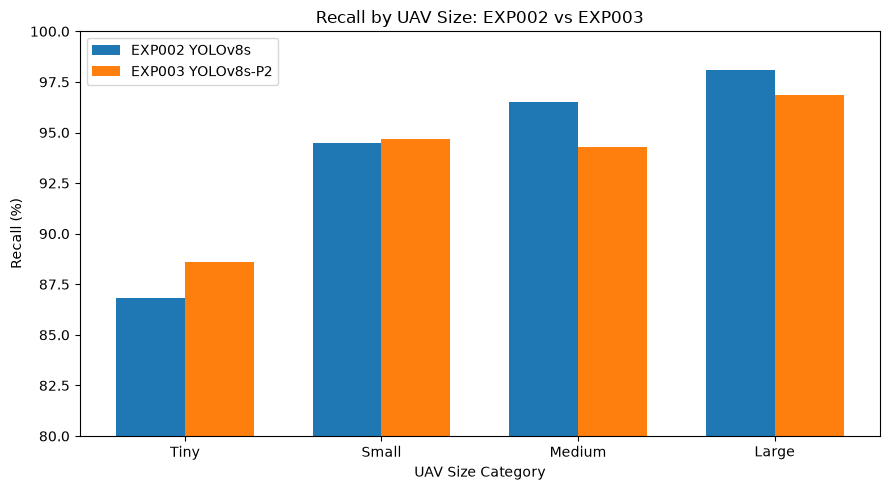

In [40]:
import matplotlib.pyplot as plt
import numpy as np

sizes = size_comparison_df["Size"]

exp002 = (
    size_comparison_df["EXP002_Recall"]
    * 100
)

exp003 = (
    size_comparison_df["EXP003_Recall"]
    * 100
)

x = np.arange(len(sizes))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    exp002,
    width,
    label="EXP002 YOLOv8s"
)

plt.bar(
    x + width/2,
    exp003,
    width,
    label="EXP003 YOLOv8s-P2"
)

plt.xticks(x, sizes)

plt.ylabel("Recall (%)")
plt.xlabel("UAV Size Category")

plt.title(
    "Recall by UAV Size: EXP002 vs EXP003"
)

plt.legend()

plt.ylim(80, 100)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "EXP002_vs_EXP003_recall_by_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

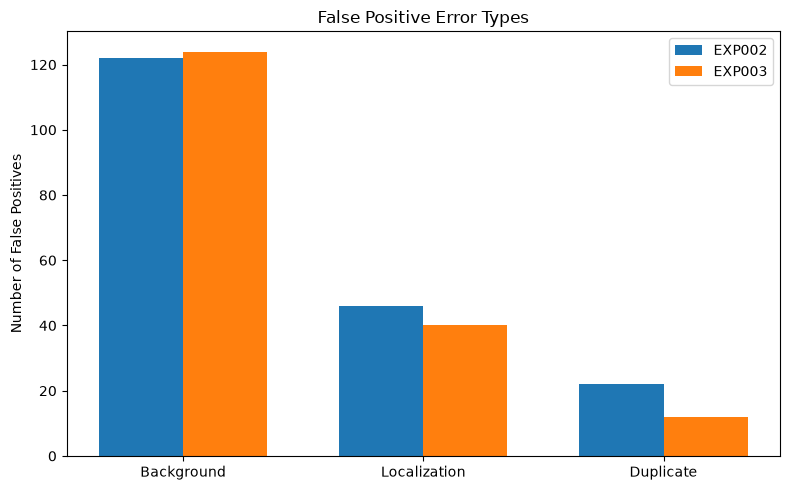

In [41]:
x = np.arange(
    len(fp_comparison_df)
)

width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width/2,
    fp_comparison_df["EXP002"],
    width,
    label="EXP002"
)

plt.bar(
    x + width/2,
    fp_comparison_df["EXP003"],
    width,
    label="EXP003"
)

plt.xticks(
    x,
    fp_comparison_df["FP_Type"]
)

plt.ylabel("Number of False Positives")

plt.title(
    "False Positive Error Types"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "EXP002_vs_EXP003_FP_types.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## EXP003 Findings

EXP003 evaluated the addition of a P2 detection head to the
YOLOv8s architecture at an input resolution of 960 pixels.

At the fixed operating point of confidence = 0.25 and
IoU = 0.50, EXP003 achieved:

- TP = 2440
- FP = 176
- FN = 181
- Precision = 93.27%
- Recall = 93.09%
- F1 = 93.18%

Compared with EXP002, the P2 model increased the number of
true-positive detections while reducing both false positives
and false negatives.

The primary objective of EXP003 was to improve the detection
of tiny UAVs. Tiny-object recall increased from 86.81% in
EXP002 to 88.61% in EXP003, reducing tiny-object false
negatives from 95 to 82.

Small-object recall also increased slightly from 94.46% to
94.67%. However, medium and large UAV recall decreased,
indicating a size-dependent trade-off.

False-positive analysis showed that the overall number of
false positives decreased from 190 to 176. Localization
errors decreased from 46 to 40 and duplicate detections
decreased from 22 to 12.

However, background false positives remained unresolved,
changing from 122 in EXP002 to 124 in EXP003. Background
confusion therefore represents the dominant remaining
false-positive error source.

These findings motivate EXP004, which will investigate
hard-negative learning while retaining the P2 architecture.